In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv(r'C:\Users\beego\Desktop\Visualcode_Courses\STEMACADEMY\streamlit_app\data\diabetes_data_rounded.csv')
df.head()

,Age,Resting Heart Rate,Weight,Mean Blood Sugar,Blood Pressure,Cholesterol,Hours of Training,Height,Diabetes
0,42.45,103.74,63.93,100.45,114.11,185.15,2.22,176.85,0
1,32.93,68.41,113.54,112.68,112.70,183.69,1.52,170.94,1
2,44.72,77.45,78.43,88.13,117.72,189.86,2.43,180.67,0
3,57.85,90.21,72.67,109.95,125.17,199.21,4.11,174.40,0
4,31.49,67.31,53.94,91.80,106.58,174.38,1.43,170.07,0


In [8]:
# Check the data structure
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nTarget column distribution:")
print(df['Diabetes'].value_counts())

Dataset shape: (9509, 9)

Column names:
['Age', 'Resting Heart Rate', 'Weight', 'Mean Blood Sugar', 'Blood Pressure', 'Cholesterol', 'Hours of Training', 'Height', 'Diabetes']

Target column distribution:
Diabetes
0    8558
1     951
Name: count, dtype: int64


In [9]:
# Prepare data for classification
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# Separate features and target
X = df.drop(columns=['Diabetes'])
y = df['Diabetes']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts())

Training set shape: (7607, 8)
Test set shape: (1902, 8)
Training target distribution:
Diabetes
0    6855
1     752
Name: count, dtype: int64


In [10]:
# Train LightGBM classifier
model = LGBMClassifier(random_state=42, verbose=-1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy percentage: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9600
Accuracy percentage: 96.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1703
           1       0.82      0.79      0.81       199

    accuracy                           0.96      1902
   macro avg       0.90      0.88      0.89      1902
weighted avg       0.96      0.96      0.96      1902



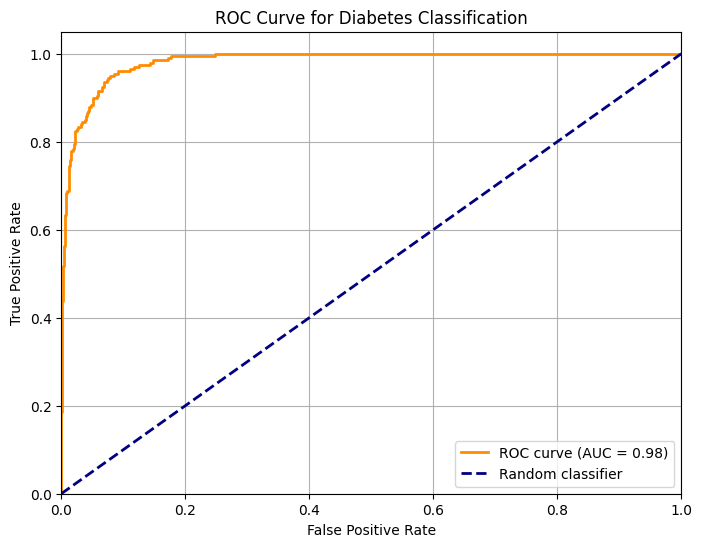

AUC Score: 0.9827


In [12]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetes Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

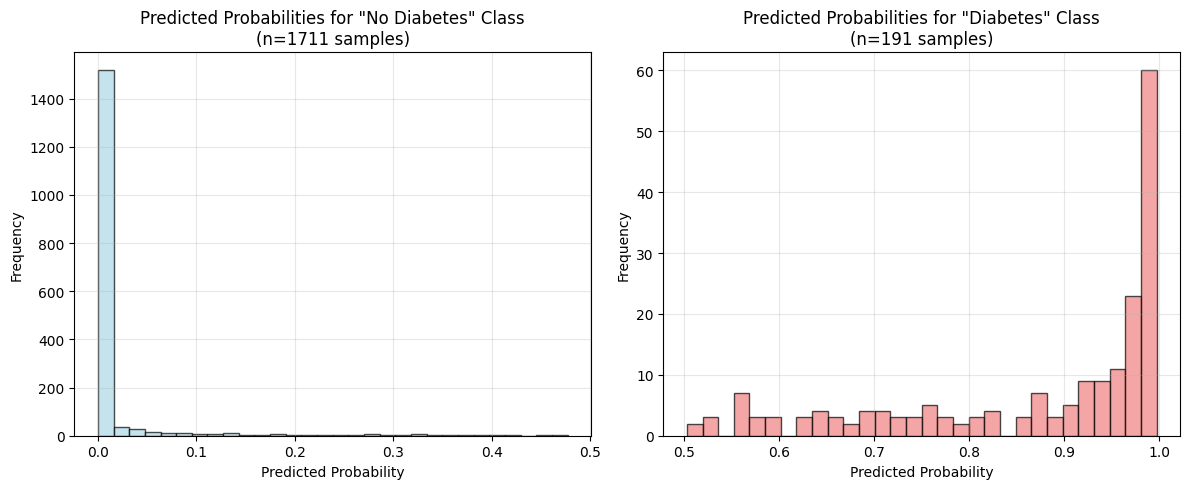

Samples predicted as No Diabetes (class 0): 1711
Samples predicted as Diabetes (class 1): 191
Total samples: 1902

No Diabetes - Probability range: 0.000 to 0.477
Diabetes - Probability range: 0.503 to 0.997


In [13]:
# Create histogram of predicted probabilities by predicted class
plt.figure(figsize=(12, 5))

# Split probabilities by predicted class
prob_no_diabetes = y_pred_proba[y_pred == 0]  # Predicted as no diabetes (class 0)
prob_diabetes = y_pred_proba[y_pred == 1]     # Predicted as diabetes (class 1)

# Create subplots
plt.subplot(1, 2, 1)
plt.hist(prob_no_diabetes, bins=30, alpha=0.7, color='lightblue', edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title(f'Predicted Probabilities for "No Diabetes" Class\n(n={len(prob_no_diabetes)} samples)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(prob_diabetes, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title(f'Predicted Probabilities for "Diabetes" Class\n(n={len(prob_diabetes)} samples)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Samples predicted as No Diabetes (class 0): {len(prob_no_diabetes)}")
print(f"Samples predicted as Diabetes (class 1): {len(prob_diabetes)}")
print(f"Total samples: {len(y_pred)}")
print(f"\nNo Diabetes - Probability range: {prob_no_diabetes.min():.3f} to {prob_no_diabetes.max():.3f}")
print(f"Diabetes - Probability range: {prob_diabetes.min():.3f} to {prob_diabetes.max():.3f}")

In [ ]:
# Feature importance
feature_importance = model.feature_importances_
feature_names = X.columns

# Create feature importance plot
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

plt.barh(range(len(importance_df)), importance_df['importance'])
plt.yticks(range(len(importance_df)), importance_df['feature'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Diabetes Classification')
plt.tight_layout()
plt.show()

print("Feature Importance Rankings:")
for i, (feature, importance) in enumerate(importance_df.sort_values('importance', ascending=False).values):
    print(f"{i+1}. {feature}: {importance:.4f}")

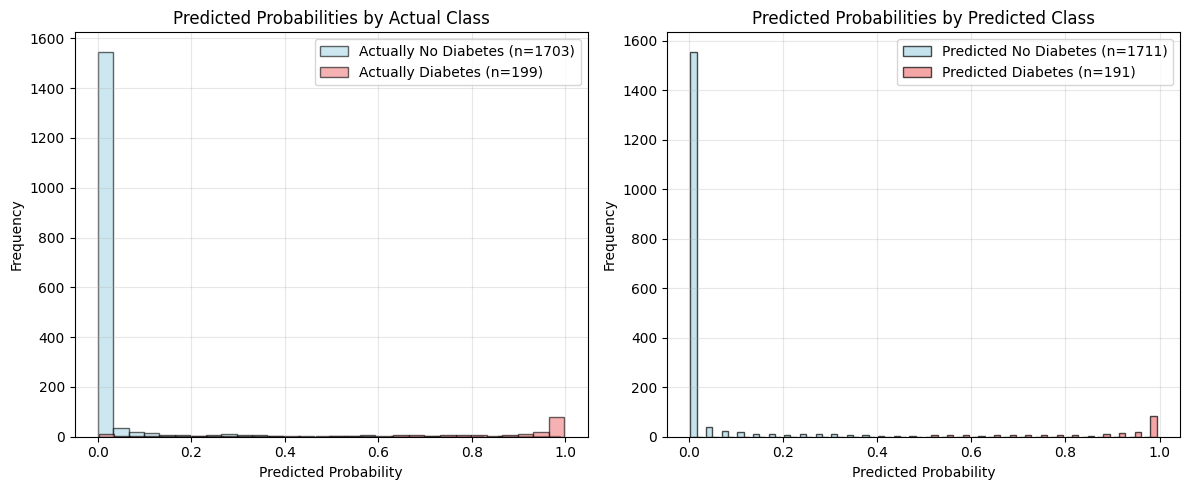

Decision threshold appears to be around 0.5

Actual class distribution in test set:
No Diabetes: 1703 (89.5%)
Diabetes: 199 (10.5%)

Predicted class distribution:
No Diabetes: 1711 (90.0%)
Diabetes: 191 (10.0%)


In [14]:
# Create overlapping histogram comparing predicted probabilities by actual class
plt.figure(figsize=(12, 5))

# Split probabilities by actual class (ground truth)
prob_actual_no_diabetes = y_pred_proba[y_test == 0]  # Actually no diabetes
prob_actual_diabetes = y_pred_proba[y_test == 1]     # Actually diabetes

# Overlapping histogram
plt.subplot(1, 2, 1)
plt.hist(prob_actual_no_diabetes, bins=30, alpha=0.6, color='lightblue', 
         label=f'Actually No Diabetes (n={len(prob_actual_no_diabetes)})', edgecolor='black')
plt.hist(prob_actual_diabetes, bins=30, alpha=0.6, color='lightcoral', 
         label=f'Actually Diabetes (n={len(prob_actual_diabetes)})', edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probabilities by Actual Class')
plt.legend()
plt.grid(True, alpha=0.3)

# Side by side comparison of predicted vs actual
plt.subplot(1, 2, 2)
plt.hist([prob_no_diabetes, prob_diabetes], bins=30, alpha=0.7, 
         color=['lightblue', 'lightcoral'], 
         label=[f'Predicted No Diabetes (n={len(prob_no_diabetes)})', 
                f'Predicted Diabetes (n={len(prob_diabetes)})'], 
         edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probabilities by Predicted Class')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show some statistics
print("Decision threshold appears to be around 0.5")
print(f"\nActual class distribution in test set:")
print(f"No Diabetes: {len(prob_actual_no_diabetes)} ({len(prob_actual_no_diabetes)/len(y_test)*100:.1f}%)")
print(f"Diabetes: {len(prob_actual_diabetes)} ({len(prob_actual_diabetes)/len(y_test)*100:.1f}%)")

print(f"\nPredicted class distribution:")
print(f"No Diabetes: {len(prob_no_diabetes)} ({len(prob_no_diabetes)/len(y_pred)*100:.1f}%)")
print(f"Diabetes: {len(prob_diabetes)} ({len(prob_diabetes)/len(y_pred)*100:.1f}%)")